# code for event segmentation procedure

### imports

In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainiak.eventseg.event as event
from os.path import join as opj
from scipy.spatial.distance import cdist

%matplotlib inline

In [2]:
# try to show progress bars for long-running cells
# to properly show progress bars, you'll need to install tqdm,
# as well as widgetsnbextension and ipywidgets to render the element
try:
    from tqdm import tnrange, tqdm_notebook as tqdm
    from functools import partial
    pbar_range = partial(tnrange, leave=False)
except ModuleNotFoundError:
    print('To enable progress bars, install tqdm module (`pip install tqdm`)')
    pbar_range = range

### set paths

In [48]:
data_dir = '../../data'

ep_data_dir = opj(data_dir, 'models', 'episodes')
rec_data_dir = opj(data_dir, 'models', 'recalls')
ep_traj_dir = opj(ep_data_dir, 'trajectories')
ep_events_dir = opj(ep_data_dir, 'events')
ep_eventseg_dir = opj(ep_data_dir, 'eventseg-models')
ep_eventtimes_dir = opj(ep_data_dir, 'event-times')
rec_events_dir = opj(rec_data_dir, 'events')

pickle_dir = opj(data_dir, 'pickles')
annot_dir = opj(data_dir, 'annotations')

### load data

In [49]:
# episode trajectories
episode_trajs = {ep : np.load(opj(ep_traj_dir, f'{ep}_trajectory.npy')) 
                 for ep in ['atlep1', 'atlep2', 'arrdev']}

annotations = {ep : pd.read_csv(opj(annot_dir, f'{ep}.csv')) 
               for ep in ['atlep1', 'atlep2', 'arrdev']}

### functions

In [50]:
def reduce_model(m, ev):
    """
    Reduce a model based on event labels
    """
    w = (np.round(ev.segments_[0])==1).astype(bool)
    return np.array([m[wi, :].mean(0) for wi in w.T])

## find optimal k for each episode trajectory

In [10]:
ep_ks = {ep : [] for ep in episode_trajs.keys()}

for ep in ep_ks.keys():
    corrmat = np.corrcoef(episode_trajs[ep])
    print(ep)
    for n_events in pbar_range(2, 51):
        ev = event.EventSegment(n_events)
        ev.fit(episode_trajs[ep])
        roundedmat = np.round(ev.segments_[0]).astype(int)
        mask = np.sum(list(map(lambda x: np.outer(x, x), roundedmat.T)), 0).astype(bool)
        within = corrmat[mask].mean()
        across = corrmat[~mask].mean()
        ep_ks[ep].append((within, across, within/across))

## plot within- & across-event correlations as a function of k

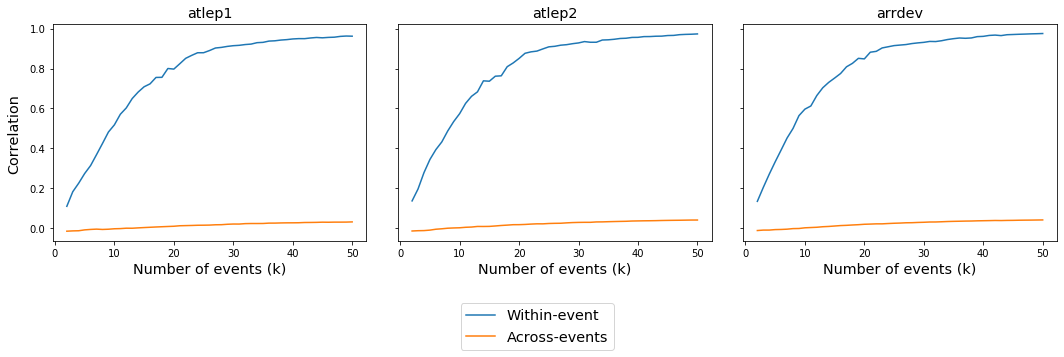

In [45]:
fig, axarr = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(18, 4)

for i, (ep, ks) in enumerate(ep_ks.items()):
    axarr[i].plot([np.nan]*2 + list(map(lambda x: x[0], ks)), label='Within-event')
    axarr[i].plot([np.nan]*2 + list(map(lambda x: x[1], ks)), label='Across-events')
    axarr[i].set_title(ep, fontsize='x-large')
    axarr[i].set_xlabel('Number of events (k)', fontsize='x-large')
    

fig.text(0.09, 0.5, 'Correlation', fontsize='x-large', va='center', rotation='vertical')
plt.subplots_adjust(wspace=.1)
plt.legend(loc=(-.9, -.5), fontsize='x-large')
plt.show()

## plot ratio of within- & across-event correlations as a function of k

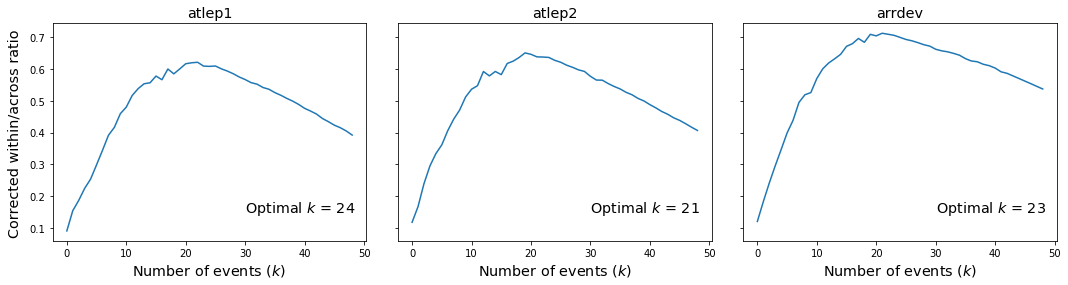

In [75]:
ep_max_ks = []
fig, axarr = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(18, 4)

for i, (ep, ks) in enumerate(ep_ks.items()):
    resample_scale = episode_trajs[ep].shape[0] / annotations[ep].shape[0]
    t = list(map(lambda x: x[0] / (x[1] - min([i[2] for i in ks])), ks))
    t /= np.max(t)
    
    for j, v in enumerate(t):
        t[j] -= (j + 2) / 250 * resample_scale
        
    maxk = np.argmax(t) + 2
    ep_max_ks.append((ep, maxk))
    
    axarr[i].plot(t)
    axarr[i].set_title(ep, fontsize='x-large')
    axarr[i].set_xlabel('Number of events ($k$)', fontsize='x-large')
    axarr[i].text(30, .15, f'Optimal $k$ = {maxk}', fontsize='x-large')

fig.text(0.09, 0.5, 'Corrected within/across ratio', fontsize='x-large', 
         va='center', rotation='vertical')
plt.subplots_adjust(wspace=.1)
plt.show()

## segment each episode using optimal k; save episode events, eventseg model, onset/offsets

In [81]:
episode_events = {}

for ep_name, max_k in ep_max_ks:
    ev = event.EventSegment(max_k)
    ev.fit(episode_trajs[ep_name])
    ep_events = reduce_model(episode_trajs[ep_name], ev)
    episode_events[ep_name] = ep_events
    
    event_times = []
    for s in ev.segments_[0].T:
        tp = np.where(np.round(s)==1)[0]
        event_times.append((tp[0], tp[-1]))
    
    np.save(opj(ep_events_dir, f'{ep_name}_events.npy'), ep_events)
    np.save(opj(ep_eventtimes_dir, f'{ep_name}_event_times.npy'), np.array(event_times))
    with open(opj(ep_eventseg_dir, f'{ep_name}_eventseg_model.p'), 'wb') as f:
        pickle.dump(ev, f)

## NOTE: recall segmentation performed using scripts in `code/cluster-scripts`

## map recall events to episode events, create average recall event models

In [82]:
# load recall event mdoels
recall_events = {ep: {} for ep in ['atlep1', 'atlep2', 'arrdev', 'delayed', 'prediction']}

for root, dirs, files in os.walk(rec_events_dir):
    turkids = [f for f in files if f.startswith('debug')]
    if turkids:
        rectype = os.path.split(root)[1]
        for turkid in turkids:
            recall_events[rectype][os.path.splitext(turkid)[0]] = np.load(opj(root, turkid))

In [92]:
for rectype, data in recall_events.items():
    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
    elif rectype == 'prediction':
        ep_events = episode_events['atlep2']
    else:
        ep_events = episode_events[rectype]

    # match recall events to episode events
    matches = np.array([(turkid, 
                         np.argmax(1 - cdist(ep_events, rec_events, 'correlation'), 
                                   axis=0)) 
                        for (turkid, rec_events) in data.items()])
    
    event_mappings = []
    avg = [[] for i in ep_events]
    for (tid, match), (turkid, r_ev) in zip(matches, data.items()):
        assert tid == turkid    # make sure ordering is consistent
        event_mappings.append((turkid, match))
        for i, m in enumerate(match):
            avg[m].append(r_ev[i,:])
                        
    # average recall for each episode event (fill with 0s if no participant recalled that event)
    avg_rec_events = np.array(list(map(lambda r: np.mean(r,0) if len(r)>0 else np.zeros((100,)), avg)))

    # save average events & event mappings
    np.save(os.path.join(rec_events_dir, rectype, 'avg_events.npy'), avg_rec_events)
    np.save(os.path.join(rec_events_dir, rectype, 'event_mappings.npy'), np.array(event_mappings))